In [3]:
#自动重载外部文件的更新
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

# 添加项目路径至path
import os
import sys
currentPath = os.path.join(os.getcwd(),"machinelearningIntro","机器学习实践/回归/多元线性回归")
sys.path.append(currentPath)

In [4]:
import pandas as pd
import seaborn as sns

In [5]:
from lineartrain_from_老师 import *

发电厂中电力输出（PE）与AT（温度), V(压力），AP（温度）,RH(压强）有关，相关测试数据如表(发电场数据.xlsx)所示，构建他们的线性关系。

绘制自变量与因变量的折线图，检查因变量与自变量之间的线性相关性

建立多元线性模型

计算拟合度R2

判断是否具有引起多重共线性的字段，如果有可以删除

检查是否有异方差性

图形化显示 预测值和测试实际值的对比折线图,观察是否为线性

In [6]:
datadir = r"D:\PythonEx\machinelearningIntro\data\发电场数据.xlsx"
df = pd.read_excel(datadir)
df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


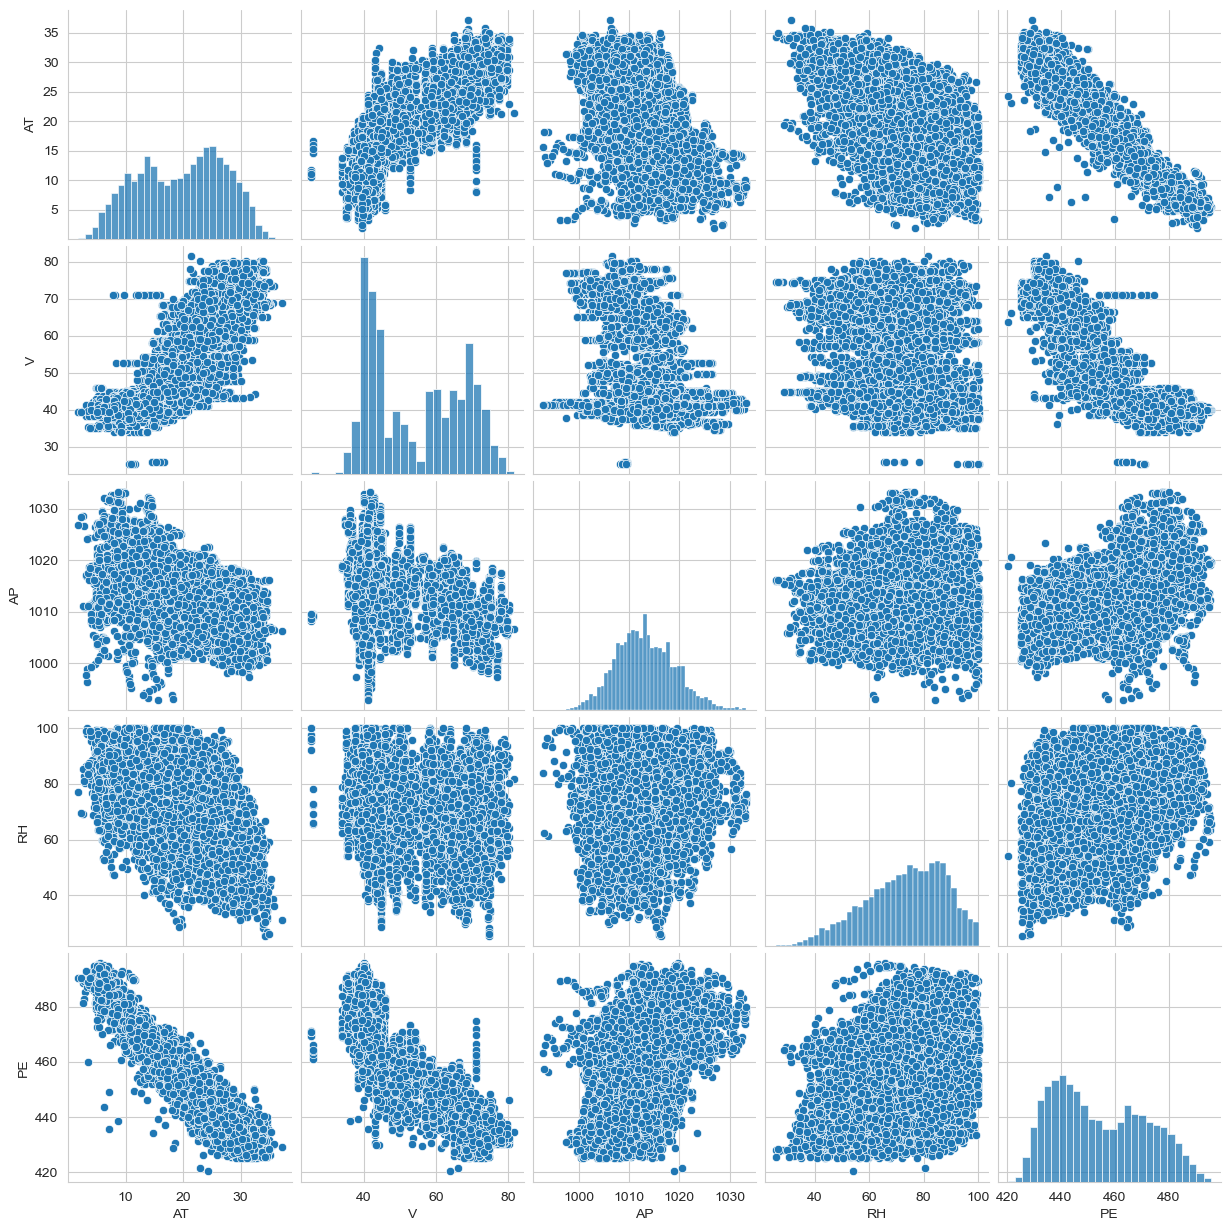

In [7]:
sns.pairplot(df)

<AxesSubplot:>

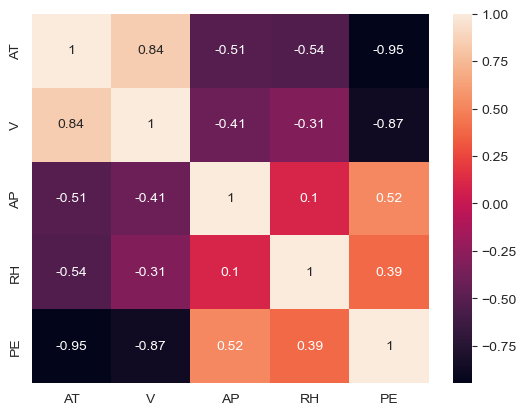

In [8]:
sns.heatmap(df.corr(),annot=True)

In [9]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

In [10]:
x_data = df[['AT', 'V', 'AP', 'RH']]
y_data = df["PE"]

# 线性回归

In [11]:
#拆分训练集和测试集
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.9, random_state=123456)


In [12]:
from sklearn import  linear_model

model = linear_model.LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)


<AxesSubplot:ylabel='Count'>

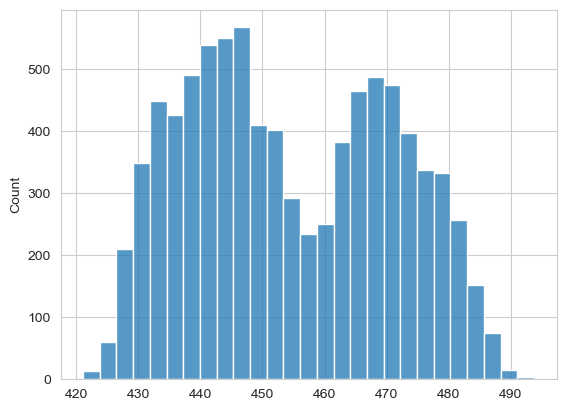

In [29]:
sns.histplot(y_pred)

## r2_score

In [13]:
r2 = r2_score(y_test,y_pred)
r2

0.927934262678185

## 多重共线性检验-VIF方差膨胀系数


In [14]:
def vif(x_data, col_i):
    from statsmodels.formula.api import ols
    cols = list(x_data.columns)
    cols.remove(col_i)
    cols_noti = cols
    formula_col = col_i + "~" + "+".join(cols_noti)
    r2 = ols(formula_col, x_data).fit().rsquared
    return 1.0/(1.0-r2)

In [15]:
for i in x_data.columns:
    print(i,"\t",vif(x_data,i))

AT 	 5.977601674191872
V 	 3.9430030401259746
AP 	 1.4526394006715808
RH 	 1.7052900320740474


## 检查异方差性

In [16]:
import statsmodels.api as sm
from patsy import dmatrices

In [22]:
y,x = dmatrices("PE~V+AP+RH+PE",data = df,return_type='dataframe')

In [23]:
model = sm.OLS(y,x).fit()

Text(0, 0.5, '残差')

D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24046 (\

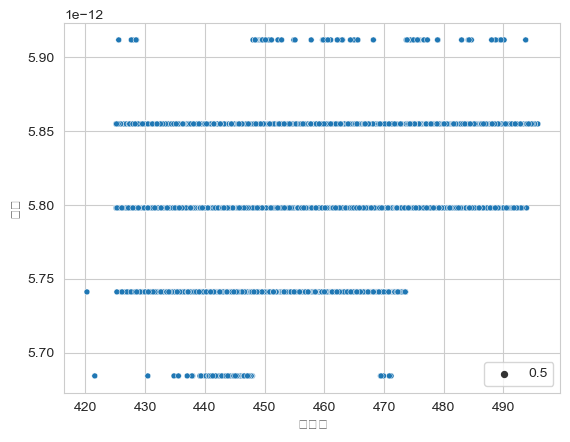

In [34]:
sns.scatterplot(x = model.fittedvalues,y = model.resid,size=0.5)
plt.xlabel("拟合值")
plt.ylabel("残差")

<AxesSubplot:>

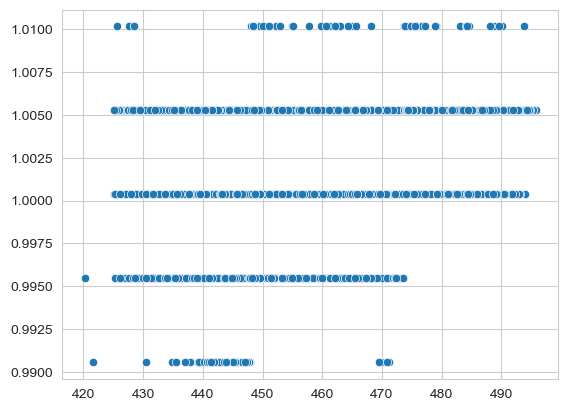

In [33]:
sns.scatterplot(x = model.fittedvalues,y = model.resid_pearson**0.5)
plt.xlabel("拟合值")
plt.ylabel("标准化残差的平方根")

In [ ]:
plt.xlabel("拟合值")
plt.hist()

D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23454 (\

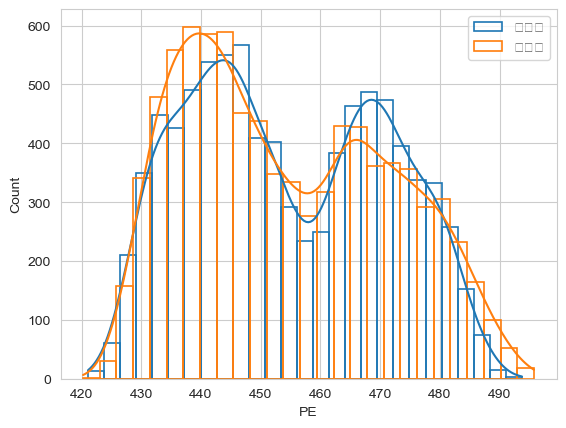

In [41]:
sns.histplot(y_pred,label="预测值",fill=False,kde=True)
sns.histplot(y_test,label="真实值",fill=False,kde=True)
plt.legend()